# 06 — Error Analysis
**BirdCLEF+ 2026 · Baseline EfficientNet-B0 · Fold 0**

Systematic analysis of the baseline model's predictions to identify the dominant
sources of error and decide what to try next.

| Metric | Value |
|--------|-------|
| Backbone | `tf_efficientnet_b0_ns` |
| Fold | 0 |
| Best val AUC (macro) | **0.9535** |
| Species | 234 |

---

In [1]:
import os, sys, warnings
os.chdir(os.path.join(os.path.dirname(os.getcwd()), ''))  # project root
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.calibration import calibration_curve
from pathlib import Path
from IPython.display import display, Audio, Markdown, HTML
import librosa
import librosa.display

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Paths ────────────────────────────────────────────────────────
EXP_DIR   = Path('experiments/baseline_effb0_fold0')
OOF_CSV   = EXP_DIR / 'oof_preds.csv'
LOG_CSV   = EXP_DIR / 'training_log.csv'
TRAIN_CSV = Path('data/raw/train.csv')
SPEC_DIR  = Path('data/processed')
AUDIO_DIR = Path('data/raw/train_audio')
FOLDS_CSV = Path('data/folds/folds.csv')

# ── Load data ────────────────────────────────────────────────────
oof   = pd.read_csv(OOF_CSV)
log   = pd.read_csv(LOG_CSV)
meta  = pd.read_csv(TRAIN_CSV)
folds = pd.read_csv(FOLDS_CSV)

# Extract species list from column names
species_cols = [c.replace('true_', '') for c in oof.columns if c.startswith('true_')]
print(f'OOF samples : {len(oof)}')
print(f'Species     : {len(species_cols)}')
print(f'Metadata    : {len(meta)} rows, columns = {list(meta.columns)}')
print(f'Train log   : {len(log)} epochs')


OOF samples : 7118
Species     : 234
Metadata    : 35549 rows, columns = ['primary_label', 'secondary_labels', 'type', 'latitude', 'longitude', 'scientific_name', 'common_name', 'class_name', 'inat_taxon_id', 'author', 'license', 'rating', 'url', 'filename', 'collection']
Train log   : 30 epochs


---
## Section 1 — Training Curves
Plot loss, AUC, and learning rate across epochs to check convergence and overfitting.

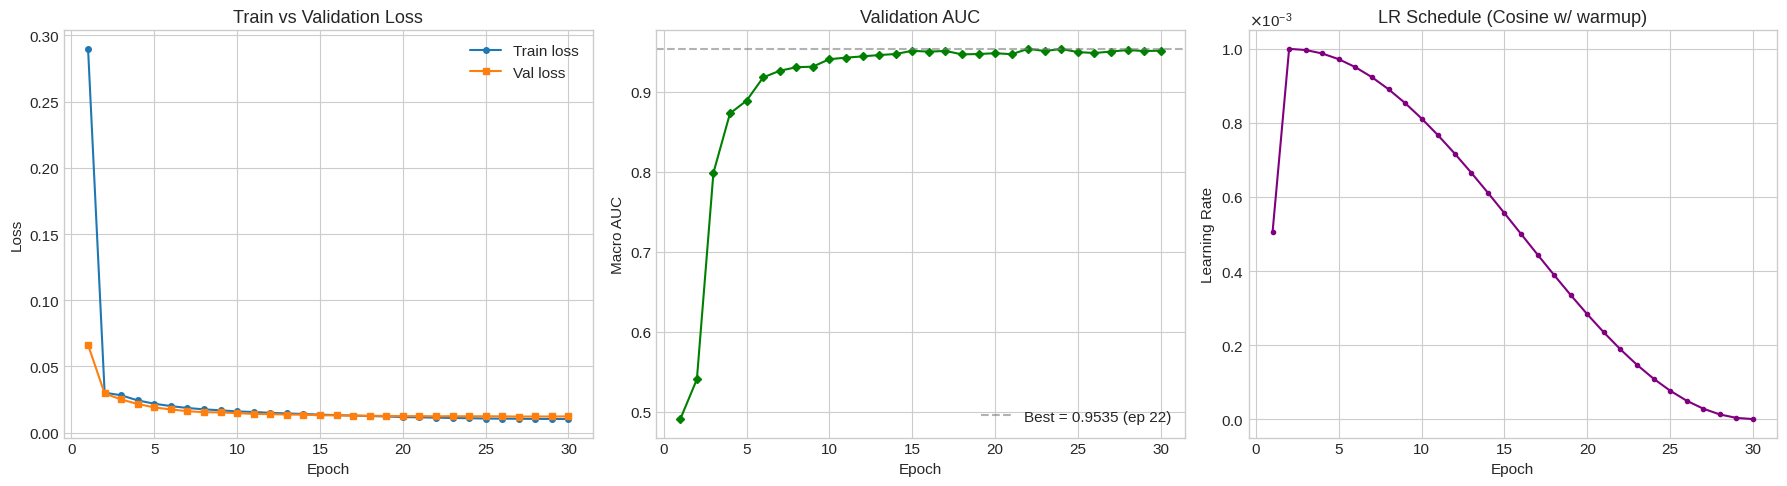

Best AUC epoch   : 22
Last-5-epoch val loss range : 0.012098 – 0.012245
Final train-val loss gap    : -0.002020  (negative → slight underfitting)
Val loss still decreasing?  : Yes


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 1a. Loss curves ──────────────────────────────────────────────
ax = axes[0]
ax.plot(log['epoch'], log['train_loss'], 'o-', label='Train loss', markersize=4)
ax.plot(log['epoch'], log['val_loss'],   's-', label='Val loss',   markersize=4)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Train vs Validation Loss')
ax.legend()

# ── 1b. Val AUC ──────────────────────────────────────────────────
ax = axes[1]
ax.plot(log['epoch'], log['val_auc'], 'D-', color='green', markersize=4)
ax.axhline(log['val_auc'].max(), ls='--', color='gray', alpha=0.6,
           label=f'Best = {log["val_auc"].max():.4f} (ep {log["val_auc"].idxmax()+1})')
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.set_title('Validation AUC')
ax.legend()

# ── 1c. Learning rate schedule ───────────────────────────────────
ax = axes[2]
ax.plot(log['epoch'], log['lr'], '.-', color='purple')
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('LR Schedule (Cosine w/ warmup)')
ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))

plt.tight_layout()
plt.show()

# ── Convergence summary ─────────────────────────────────────────
best_ep = int(log['val_auc'].idxmax()) + 1
last5_val = log['val_loss'].iloc[-5:].values
gap = log['train_loss'].iloc[-1] - log['val_loss'].iloc[-1]
print(f'Best AUC epoch   : {best_ep}')
print(f'Last-5-epoch val loss range : {last5_val.min():.6f} – {last5_val.max():.6f}')
print(f'Final train-val loss gap    : {gap:.6f}  ({"negative → slight underfitting" if gap < 0 else "positive → some overfitting"})')
print(f'Val loss still decreasing?  : {"Yes" if log["val_loss"].iloc[-1] < log["val_loss"].iloc[-6] else "Plateaued"}')


---
## Section 2 — Per-Species AUC Breakdown
Compute individual ROC-AUC for each of the 234 species and relate performance to sample count.

In [3]:
# ── Compute per-species AUC ──────────────────────────────────────
per_species = []
for sp in species_cols:
    y_true = oof[f'true_{sp}'].values
    y_pred = oof[f'pred_{sp}'].values
    n_pos  = int(y_true.sum())
    n_neg  = int(len(y_true) - n_pos)
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_pred)
    per_species.append({'species': sp, 'auc': auc, 'n_positive': n_pos})

sp_df = pd.DataFrame(per_species).sort_values('auc', ascending=False).reset_index(drop=True)

# Merge metadata: sample count per species, collection breakdown, class
sp_meta = meta.groupby('primary_label').agg(
    total_samples=('filename', 'count'),
    mean_rating=('rating', 'mean'),
    class_name=('class_name', 'first'),
    common_name=('common_name', 'first'),
    scientific_name=('scientific_name', 'first'),
).reset_index().rename(columns={'primary_label': 'species'})

# Collection source breakdown per species
coll_ct = meta.groupby(['primary_label', 'collection']).size().unstack(fill_value=0)
coll_ct.columns = [f'n_{c}' for c in coll_ct.columns]
coll_ct = coll_ct.reset_index().rename(columns={'primary_label': 'species'})

sp_df = sp_df.merge(sp_meta, on='species', how='left').merge(coll_ct, on='species', how='left')

# Fold-0 val count (how many positives in the val set for this species)
fold0_val = folds[folds['fold'] == 0]
fold0_counts = fold0_val['primary_label'].value_counts().rename('n_val_fold0').reset_index()
fold0_counts.columns = ['species', 'n_val_fold0']
sp_df = sp_df.merge(fold0_counts, on='species', how='left')
sp_df['n_val_fold0'] = sp_df['n_val_fold0'].fillna(0).astype(int)

overall_auc = sp_df['auc'].mean()
print(f'Macro-averaged AUC across {sp_df["auc"].notna().sum()} evaluable species: {overall_auc:.4f}')
print(f'Species with AUC = NaN (no positive val samples): {sp_df["auc"].isna().sum()}')


Macro-averaged AUC across 206 evaluable species: 0.9535
Species with AUC = NaN (no positive val samples): 28


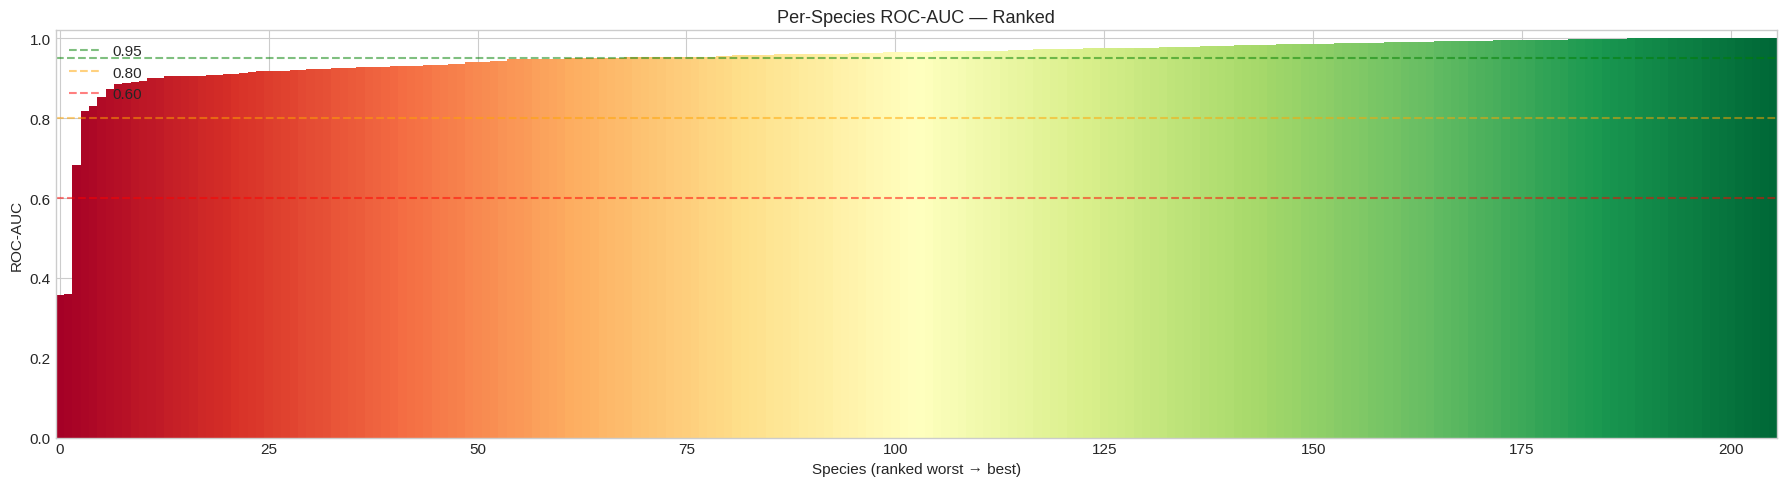

In [4]:
# ── 2a. Ranked bar chart of per-species AUC ──────────────────────
fig, ax = plt.subplots(figsize=(18, 5))
valid = sp_df.dropna(subset=['auc']).sort_values('auc')
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(valid)))
ax.bar(range(len(valid)), valid['auc'].values, color=colors, width=1.0, edgecolor='none')
ax.axhline(0.95, ls='--', color='green', alpha=0.5, label='0.95')
ax.axhline(0.80, ls='--', color='orange', alpha=0.5, label='0.80')
ax.axhline(0.60, ls='--', color='red', alpha=0.5, label='0.60')
ax.set_xlabel('Species (ranked worst → best)')
ax.set_ylabel('ROC-AUC')
ax.set_title('Per-Species ROC-AUC — Ranked')
ax.legend()
ax.set_xlim(-0.5, len(valid) - 0.5)
ax.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()


In [5]:
# ── 2b. Worst 20 species ────────────────────────────────────────
print('=== 20 WORST-PERFORMING SPECIES ===')
worst20 = sp_df.dropna(subset=['auc']).nsmallest(20, 'auc')
display_cols = ['species', 'common_name', 'class_name', 'auc', 'n_positive',
                'total_samples', 'n_val_fold0', 'mean_rating']
for c in ['n_XC', 'n_iNat']:
    if c in worst20.columns:
        display_cols.append(c)
display(worst20[display_cols].reset_index(drop=True).style.format({'auc': '{:.4f}', 'mean_rating': '{:.1f}'}))


=== 20 WORST-PERFORMING SPECIES ===


,species,common_name,class_name,auc,n_positive,total_samples,n_val_fold0,mean_rating,n_XC,n_iNat
0,23724,Waxy Monkey Tree Frog,Amphibia,0.3569,1,1.000000,1,0.0,0.000000,1.000000
1,116570,Southern Spectacled Caiman,Reptilia,0.3600,1,1.000000,1,0.0,0.000000,1.000000
2,70711,Cei's White-lipped Frog,Amphibia,0.6827,1,2.000000,1,0.0,0.000000,2.000000
3,209233,Feral Horse,Mammalia,0.8170,1,2.000000,1,0.0,0.000000,2.000000
4,516975,Hooded Capuchin,Mammalia,0.8304,1,1.000000,1,0.0,0.000000,1.000000
5,74580,Black-tailed Marmoset,Mammalia,0.8523,1,3.000000,1,1.0,1.000000,2.000000
6,grekis,Great Kiskadee,Aves,0.8729,224,482.000000,96,1.6,181.000000,301.000000
7,bafcur1,Bare-faced Curassow,Aves,0.8844,12,51.000000,11,3.6,45.000000,6.000000
8,23150,Central Dwarf Frog,Amphibia,0.8877,1,1.000000,1,0.0,0.000000,1.000000
9,rufhor2,Rufous Hornero,Aves,0.8901,118,315.000000,63,1.9,163.000000,152.000000


In [6]:
# ── 2c. Best 20 species ─────────────────────────────────────────
print('=== 20 BEST-PERFORMING SPECIES ===')
best20 = sp_df.dropna(subset=['auc']).nlargest(20, 'auc')
display(best20[display_cols].reset_index(drop=True).style.format({'auc': '{:.4f}', 'mean_rating': '{:.1f}'}))


=== 20 BEST-PERFORMING SPECIES ===


,species,common_name,class_name,auc,n_positive,total_samples,n_val_fold0,mean_rating,n_XC,n_iNat
0,22930,Basin White-lipped Frog,Amphibia,1.0000,1,6.000000,1,0.5,1.000000,5.000000
1,22956,Mustached Frog,Amphibia,1.0000,7,32.000000,7,0.1,1.000000,31.000000
2,22983,Pepper Frog,Amphibia,1.0000,2,10.000000,2,0.0,0.000000,10.000000
3,760266,Prionacris erosa,Insecta,1.0000,2,7.000000,2,0.0,0.000000,7.000000
4,24287,Brown-bordered Snouted Tree Frog,Amphibia,1.0000,2,11.000000,2,1.5,4.000000,7.000000
5,23176,Cope's Swamp Froglet,Amphibia,1.0000,1,4.000000,1,1.2,1.000000,3.000000
6,67107,Rococo Toad,Amphibia,1.0000,3,14.000000,3,1.2,4.000000,10.000000
7,67252,Milk Frog,Amphibia,1.0000,1,6.000000,1,2.2,3.000000,3.000000
8,738183,White-coated Titi,Mammalia,1.0000,1,5.000000,1,1.0,1.000000,4.000000
9,ocecra1,Ocellated Crake,Aves,1.0000,3,15.000000,3,0.0,0.000000,15.000000


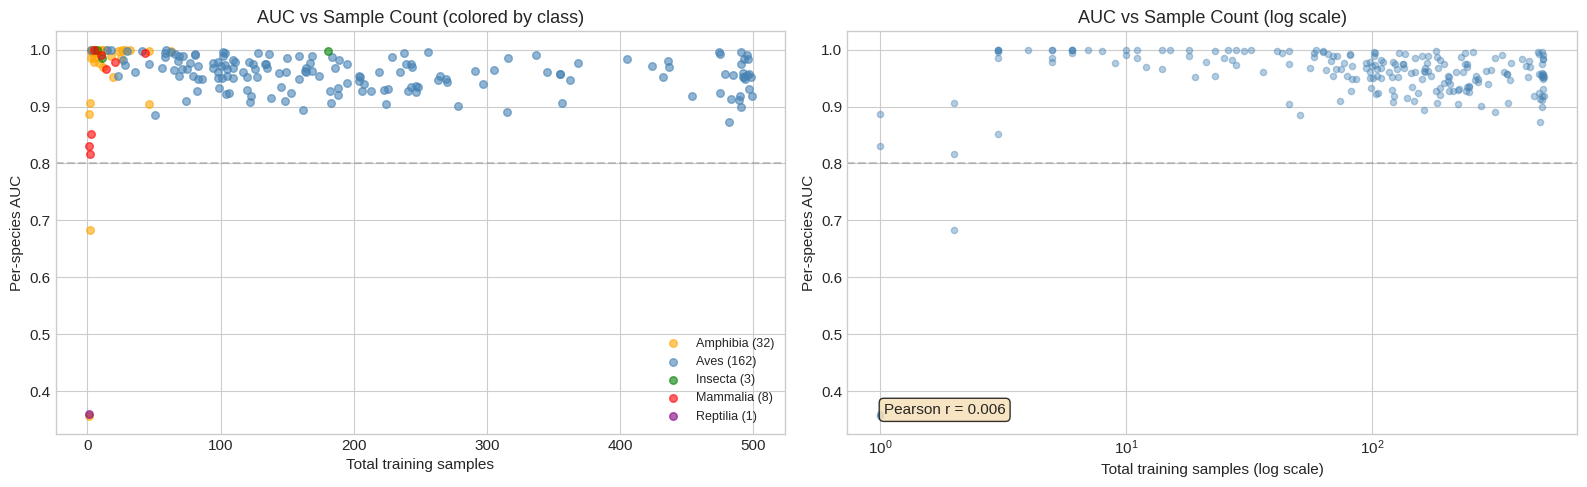

In [7]:
# ── 2d. AUC vs sample count scatter ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
valid = sp_df.dropna(subset=['auc'])
class_colors = {'Aves': 'steelblue', 'Amphibia': 'orange', 'Insecta': 'green',
                'Mammalia': 'red', 'Reptilia': 'purple'}
for cls, grp in valid.groupby('class_name'):
    ax.scatter(grp['total_samples'], grp['auc'], alpha=0.6, s=30,
               label=f'{cls} ({len(grp)})', color=class_colors.get(cls, 'gray'))
ax.set_xlabel('Total training samples')
ax.set_ylabel('Per-species AUC')
ax.set_title('AUC vs Sample Count (colored by class)')
ax.axhline(0.80, ls='--', color='gray', alpha=0.4)
ax.legend(fontsize=9)

ax = axes[1]
ax.scatter(valid['total_samples'], valid['auc'], alpha=0.4, s=20, color='steelblue')
ax.set_xlabel('Total training samples (log scale)')
ax.set_ylabel('Per-species AUC')
ax.set_title('AUC vs Sample Count (log scale)')
ax.set_xscale('log')
ax.axhline(0.80, ls='--', color='gray', alpha=0.4)

# Correlation
corr = valid[['total_samples', 'auc']].corr().iloc[0, 1]
ax.annotate(f'Pearson r = {corr:.3f}', xy=(0.05, 0.05), xycoords='axes fraction',
            fontsize=11, bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))

plt.tight_layout()
plt.show()


---
## Section 3 — Failure Buckets
Group species by performance tier and profile each bucket.

In [9]:
# ── Define buckets ───────────────────────────────────────────────
def bucket_label(auc):
    if pd.isna(auc):
        return 'N/A'
    if auc >= 0.95:
        return 'Strong (≥0.95)'
    if auc >= 0.80:
        return 'Decent (0.80–0.95)'
    if auc >= 0.60:
        return 'Weak (0.60–0.80)'
    return 'Failing (<0.60)'

sp_df['bucket'] = sp_df['auc'].apply(bucket_label)

bucket_order = ['Strong (≥0.95)', 'Decent (0.80–0.95)', 'Weak (0.60–0.80)', 'Failing (<0.60)', 'N/A']
bucket_summary = []
for bk in bucket_order:
    sub = sp_df[sp_df['bucket'] == bk]
    if len(sub) == 0:
        continue
    row = {
        'Bucket': bk,
        'Num species': len(sub),
        'Median samples': sub['total_samples'].median(),
        'Mean AUC': sub['auc'].mean() if sub['auc'].notna().any() else np.nan,
        'Median rating': sub['mean_rating'].median(),
    }
    # Dominant class
    vc = sub['class_name'].dropna().value_counts()
    row['Dominant class'] = vc.index[0] if len(vc) > 0 else 'Unknown'
    row['Non-Aves count'] = sub['class_name'].dropna().ne('Aves').sum()
    # Dominant collection source (majority source per species)
    if 'n_XC' in sub.columns and 'n_iNat' in sub.columns:
        sub = sub.copy()
        sub['dominant_src'] = np.where(sub['n_XC'] >= sub['n_iNat'], 'XC', 'iNat')
        row['Majority XC'] = (sub['dominant_src'] == 'XC').sum()
        row['Majority iNat'] = (sub['dominant_src'] == 'iNat').sum()
    bucket_summary.append(row)

bk_df = pd.DataFrame(bucket_summary)
display(bk_df.style.format({
    'Median samples': '{:.0f}',
    'Mean AUC': '{:.4f}',
    'Median rating': '{:.1f}',
}))

,Bucket,Num species,Median samples,Mean AUC,Median rating,Dominant class,Non-Aves count,Majority XC,Majority iNat
0,Strong (≥0.95),145,103,0.9779,2.6,Aves,35,97,48
1,Decent (0.80–0.95),58,205,0.9179,2.9,Aves,6,48,10
2,Weak (0.60–0.80),1,2,0.6827,0.0,Amphibia,1,0,1
3,Failing (<0.60),2,1,0.3584,0.0,Reptilia,2,0,2
4,N/A,28,nan,nan,nan,Unknown,0,0,28


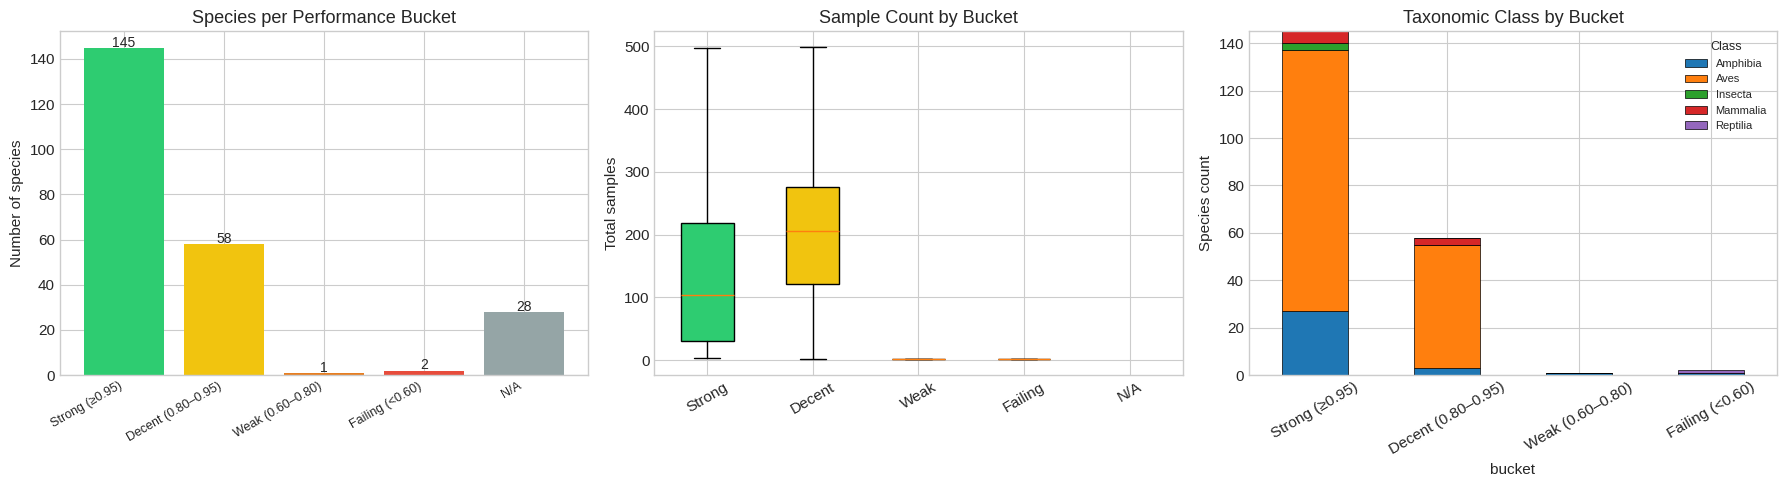

In [10]:
# ── Bucket composition visuals ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 3a. Species count per bucket
ax = axes[0]
counts = sp_df['bucket'].value_counts().reindex(bucket_order).dropna()
colors_bk = {'Strong (≥0.95)': '#2ecc71', 'Decent (0.80–0.95)': '#f1c40f',
             'Weak (0.60–0.80)': '#e67e22', 'Failing (<0.60)': '#e74c3c', 'N/A': '#95a5a6'}
ax.bar(range(len(counts)), counts.values,
       color=[colors_bk.get(b, 'gray') for b in counts.index])
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Number of species')
ax.set_title('Species per Performance Bucket')
for i, v in enumerate(counts.values):
    ax.text(i, v + 0.5, str(int(v)), ha='center', fontsize=10)

# 3b. Sample count distribution per bucket
ax = axes[1]
bk_data = [sp_df[sp_df['bucket'] == b]['total_samples'].values
           for b in bucket_order if b in sp_df['bucket'].values]
bk_labels = [b for b in bucket_order if b in sp_df['bucket'].values]
bp = ax.boxplot(bk_data, labels=[b.split('(')[0].strip() for b in bk_labels],
                patch_artist=True, showfliers=False)
for patch, bk in zip(bp['boxes'], bk_labels):
    patch.set_facecolor(colors_bk.get(bk, 'gray'))
ax.set_ylabel('Total samples')
ax.set_title('Sample Count by Bucket')
ax.tick_params(axis='x', rotation=30)

# 3c. Class breakdown per bucket
ax = axes[2]
ct = pd.crosstab(sp_df['bucket'], sp_df['class_name'])
ct = ct.reindex(bucket_order).dropna(how='all')
ct.plot.bar(stacked=True, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_ylabel('Species count')
ax.set_title('Taxonomic Class by Bucket')
ax.legend(title='Class', fontsize=8, title_fontsize=9)
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


---
## Section 4 — Confusion Analysis
For the worst-performing species, which other species does the model confuse them with?

In [11]:
# ── Find top confusions for the 10 worst species ────────────────
worst10 = sp_df.dropna(subset=['auc']).nsmallest(10, 'auc')

confusion_rows = []
for _, row in worst10.iterrows():
    sp = row['species']
    # Rows where this species is the true label
    mask = oof[f'true_{sp}'] == 1
    if mask.sum() == 0:
        continue
    # Average predicted probability for every OTHER species when true = sp
    mean_preds = {}
    for other_sp in species_cols:
        if other_sp == sp:
            continue
        mean_preds[other_sp] = oof.loc[mask, f'pred_{other_sp}'].mean()
    top_confused = sorted(mean_preds.items(), key=lambda x: x[1], reverse=True)[:5]
    for rank, (other_sp, mean_pred) in enumerate(top_confused, 1):
        other_name = sp_meta.loc[sp_meta['species'] == other_sp, 'common_name'].values
        other_name = other_name[0] if len(other_name) > 0 else other_sp
        confusion_rows.append({
            'true_species': sp,
            'true_name': row['common_name'],
            'true_auc': row['auc'],
            'rank': rank,
            'confused_with': other_sp,
            'confused_name': other_name,
            'mean_false_pred': mean_pred,
        })

conf_df = pd.DataFrame(confusion_rows)

print('=== Top confusions for the 10 worst species ===')
print('(mean predicted probability of the confused species when the true species is active)\n')
for sp in worst10['species'].values:
    sub = conf_df[conf_df['true_species'] == sp].head(3)
    if len(sub) == 0:
        continue
    name = sub['true_name'].iloc[0]
    auc_val = sub['true_auc'].iloc[0]
    print(f'▸ {sp} ({name})  AUC={auc_val:.4f}')
    for _, r in sub.iterrows():
        print(f'    → confused with {r["confused_with"]} ({r["confused_name"]}): '
              f'mean pred = {r["mean_false_pred"]:.4f}')
    print()


=== Top confusions for the 10 worst species ===
(mean predicted probability of the confused species when the true species is active)

▸ 23724 (Waxy Monkey Tree Frog)  AUC=0.3569
    → confused with astcra1 (Ash-throated Crake): mean pred = 0.0745
    → confused with fepowl (Ferruginous Pygmy Owl): mean pred = 0.0241
    → confused with thlwre1 (Thrush-like Wren): mean pred = 0.0190

▸ 116570 (Southern Spectacled Caiman)  AUC=0.3600
    → confused with baffal1 (Barred Forest-Falcon): mean pred = 0.7603
    → confused with coffal1 (Collared Forest-Falcon): mean pred = 0.0185
    → confused with astcra1 (Ash-throated Crake): mean pred = 0.0179

▸ 70711 (Cei's White-lipped Frog)  AUC=0.6827
    → confused with 24279 (Lesser Snouted Tree Frog): mean pred = 0.3438
    → confused with 24285 (Snouted Tree Frog): mean pred = 0.3354
    → confused with 67107 (Rococo Toad): mean pred = 0.1128

▸ 209233 (Feral Horse)  AUC=0.8170
    → confused with baymac (Blue-and-yellow Macaw): mean pred = 0.220

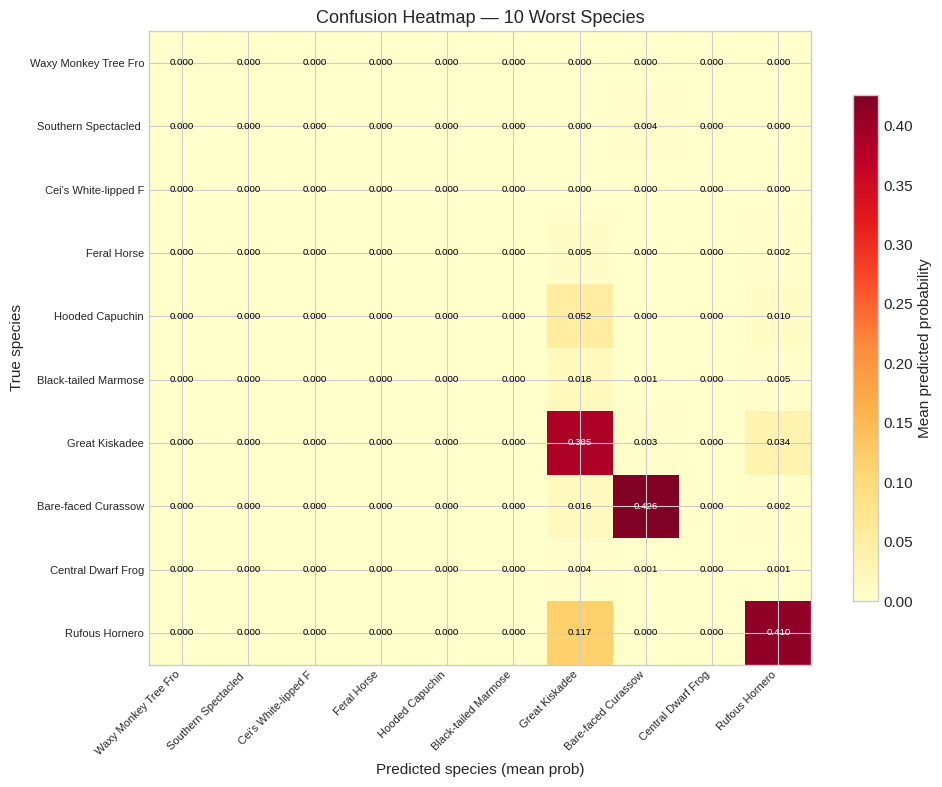

In [12]:
# ── Mini confusion heatmap for worst 10 ──────────────────────────
worst10_species = worst10['species'].tolist()
conf_matrix = np.zeros((len(worst10_species), len(worst10_species)))

for i, sp_true in enumerate(worst10_species):
    mask = oof[f'true_{sp_true}'] == 1
    if mask.sum() == 0:
        continue
    for j, sp_pred in enumerate(worst10_species):
        conf_matrix[i, j] = oof.loc[mask, f'pred_{sp_pred}'].mean()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, cmap='YlOrRd', aspect='auto')
names_short = []
for sp in worst10_species:
    nm = sp_meta.loc[sp_meta['species'] == sp, 'common_name'].values
    names_short.append((nm[0][:20] if len(nm) > 0 else sp)[:20])

ax.set_xticks(range(len(worst10_species)))
ax.set_yticks(range(len(worst10_species)))
ax.set_xticklabels(names_short, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(names_short, fontsize=8)
ax.set_xlabel('Predicted species (mean prob)')
ax.set_ylabel('True species')
ax.set_title('Confusion Heatmap — 10 Worst Species')

for i in range(len(worst10_species)):
    for j in range(len(worst10_species)):
        val = conf_matrix[i, j]
        color = 'white' if val > conf_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=7, color=color)

plt.colorbar(im, ax=ax, shrink=0.8, label='Mean predicted probability')
plt.tight_layout()
plt.show()


=== Spectrogram comparison for top 3 confused pairs ===



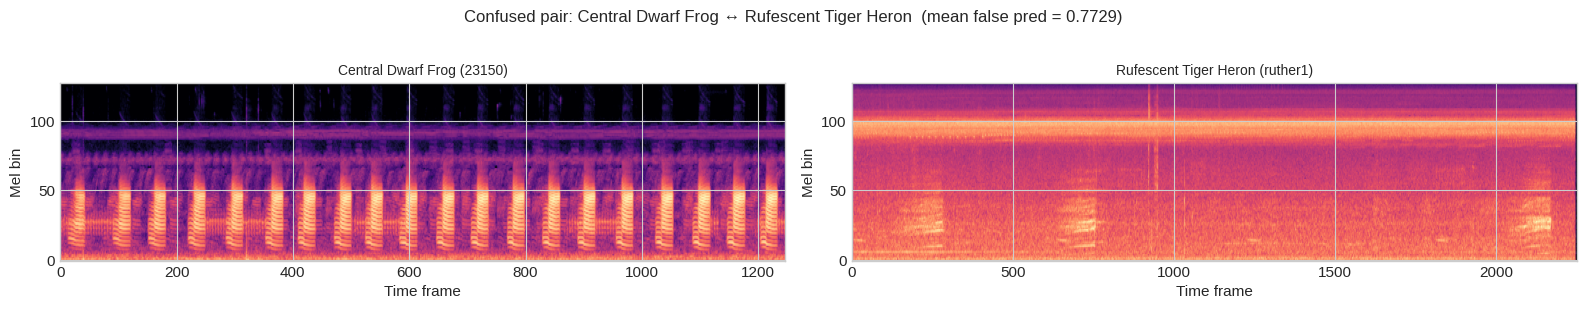

🔊 Central Dwarf Frog (23150): 23150/iNat1243039.ogg


🔊 Rufescent Tiger Heron (ruther1): ruther1/iNat682015.ogg


---



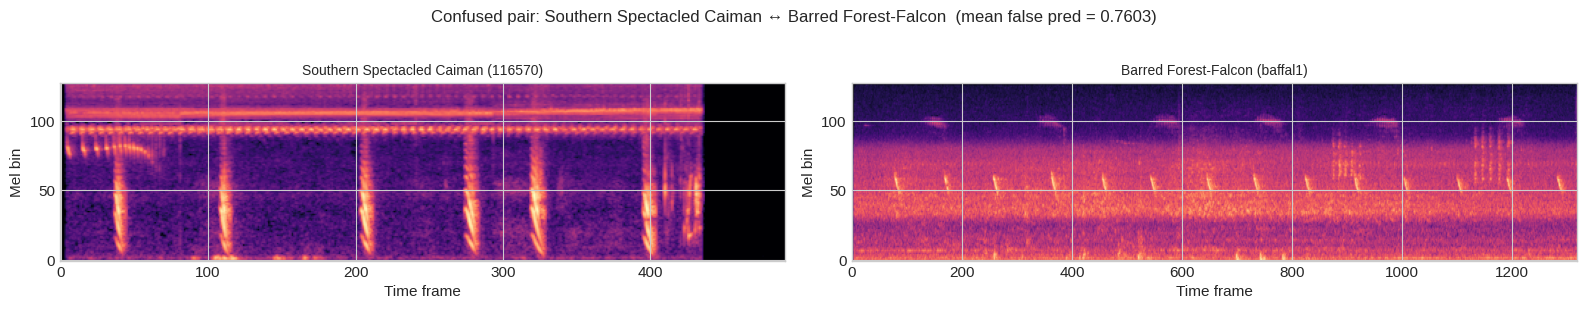

🔊 Southern Spectacled Caiman (116570): 116570/iNat1460166.ogg


🔊 Barred Forest-Falcon (baffal1): baffal1/iNat580803.ogg


---



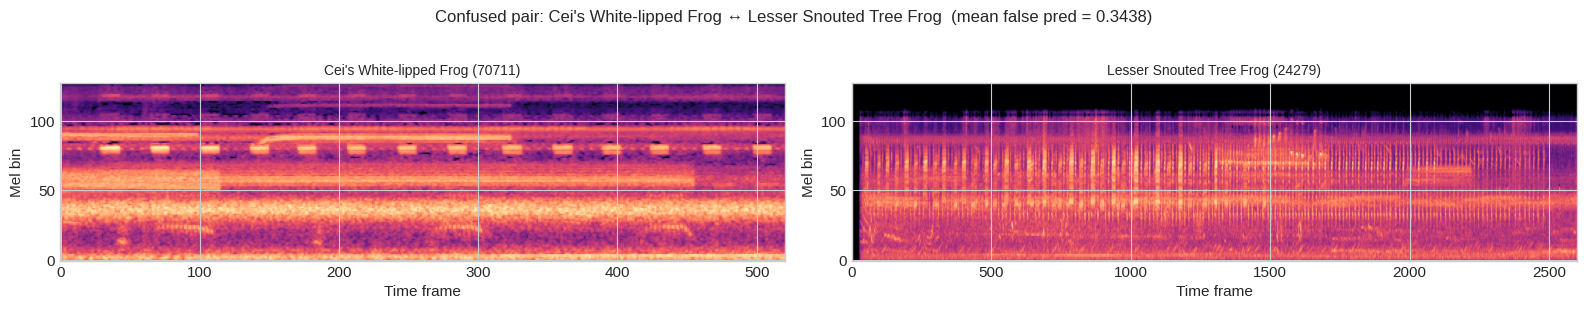

🔊 Cei's White-lipped Frog (70711): 70711/iNat1301472.ogg


🔊 Lesser Snouted Tree Frog (24279): 24279/iNat845210.ogg


---



In [13]:
# ── Side-by-side spectrograms for top 3 confused pairs ───────────
print('=== Spectrogram comparison for top 3 confused pairs ===\n')

# Get the 3 pairs with highest cross-confusion
top_pairs = conf_df.sort_values('mean_false_pred', ascending=False).head(3)

for _, pair in top_pairs.iterrows():
    sp_a = pair['true_species']
    sp_b = pair['confused_with']
    name_a = pair['true_name']
    name_b = pair['confused_name']

    # Find an example file for each species
    files_a = meta[meta['primary_label'] == sp_a]['filename'].values
    files_b = meta[meta['primary_label'] == sp_b]['filename'].values

    if len(files_a) == 0 or len(files_b) == 0:
        print(f'Skipping {sp_a} vs {sp_b}: no audio files found')
        continue

    fig, axes = plt.subplots(1, 2, figsize=(16, 3))

    for idx, (sp, files, name) in enumerate([(sp_a, files_a, name_a), (sp_b, files_b, name_b)]):
        ax = axes[idx]
        # Try loading cached spectrogram first, fall back to audio
        spec_loaded = False
        for fname in files[:5]:
            npy_path = SPEC_DIR / Path(fname).with_suffix('.npy')
            if npy_path.exists():
                spec = np.load(str(npy_path))
                ax.imshow(spec, aspect='auto', origin='lower', cmap='magma')
                ax.set_title(f'{name} ({sp})', fontsize=10)
                ax.set_xlabel('Time frame')
                ax.set_ylabel('Mel bin')
                spec_loaded = True
                break

        if not spec_loaded:
            # Try loading raw audio
            for fname in files[:5]:
                audio_path = AUDIO_DIR / fname
                if audio_path.exists():
                    try:
                        y, sr = librosa.load(str(audio_path), sr=32000, duration=10)
                        S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                                          fmax=16000, hop_length=512)
                        S_db = librosa.power_to_db(S, ref=np.max)
                        librosa.display.specshow(S_db, sr=sr, hop_length=512,
                                                 x_axis='time', y_axis='mel', ax=ax, cmap='magma')
                        ax.set_title(f'{name} ({sp})', fontsize=10)
                        spec_loaded = True
                        break
                    except Exception as e:
                        continue

        if not spec_loaded:
            ax.text(0.5, 0.5, f'No spectrogram\navailable for\n{sp}',
                    ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{name} ({sp})', fontsize=10)

    plt.suptitle(f'Confused pair: {name_a} ↔ {name_b}  (mean false pred = {pair["mean_false_pred"]:.4f})',
                 fontsize=12, y=1.02)
    plt.tight_layout()
    plt.show()

    # Audio playback widgets
    for sp, files, name in [(sp_a, files_a, name_a), (sp_b, files_b, name_b)]:
        for fname in files[:3]:
            audio_path = AUDIO_DIR / fname
            if audio_path.exists():
                print(f'🔊 {name} ({sp}): {fname}')
                display(Audio(str(audio_path)))
                break
    print('---\n')


---
## Section 5 — Confidence & Calibration
Are the model's predicted probabilities well-separated and trustworthy?

In [14]:
# ── Gather all true labels and predictions into flat arrays ──────
all_true = []
all_pred = []
for sp in species_cols:
    all_true.append(oof[f'true_{sp}'].values)
    all_pred.append(oof[f'pred_{sp}'].values)

all_true = np.concatenate(all_true)
all_pred = np.concatenate(all_pred)

pos_preds = all_pred[all_true == 1]
neg_preds = all_pred[all_true == 0]

print(f'Total label entries : {len(all_true):,}')
print(f'  Positives         : {int(all_true.sum()):,}  ({all_true.mean()*100:.2f}%)')
print(f'  Negatives         : {int((1-all_true).sum()):,}')
print(f'Positive pred stats : mean={pos_preds.mean():.4f}, median={np.median(pos_preds):.4f}')
print(f'Negative pred stats : mean={neg_preds.mean():.6f}, median={np.median(neg_preds):.6f}')


Total label entries : 1,665,612
  Positives         : 8,623  (0.52%)
  Negatives         : 1,656,989
Positive pred stats : mean=0.5650, median=0.7905
Negative pred stats : mean=0.002042, median=0.000014


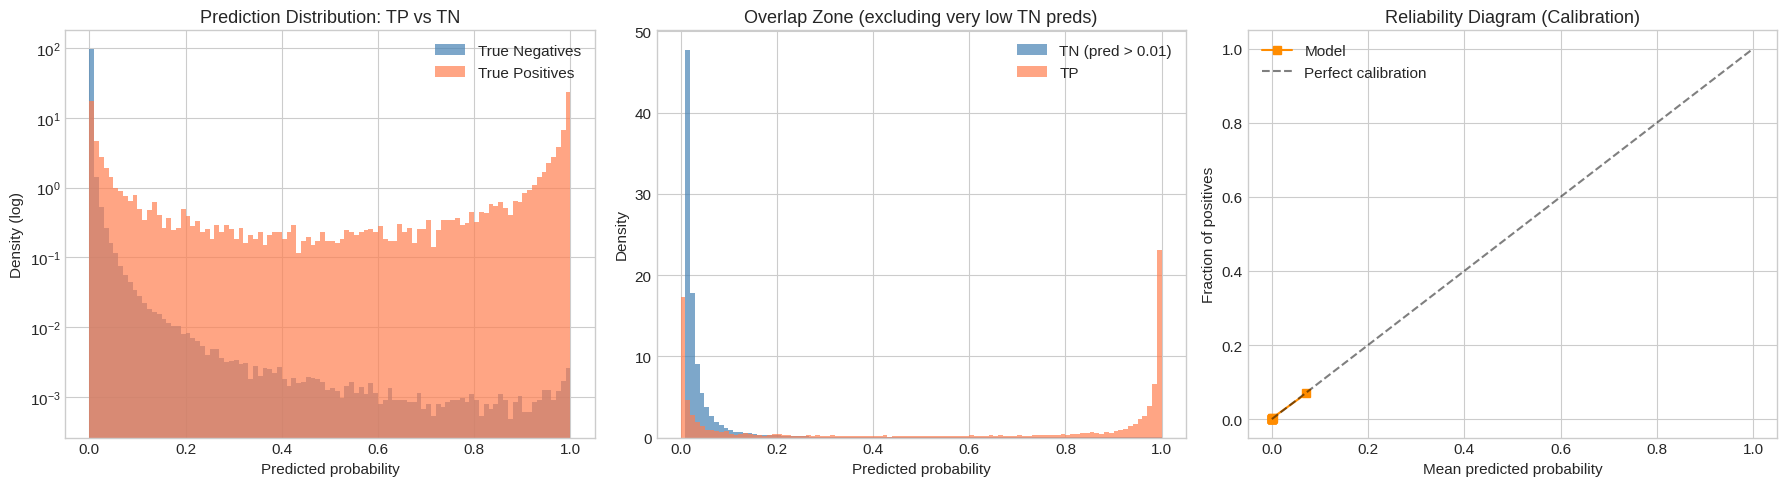

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 5a. Histogram of predicted probs ────────────────────────────
ax = axes[0]
ax.hist(neg_preds, bins=100, alpha=0.7, label='True Negatives', color='steelblue',
        density=True, log=True)
ax.hist(pos_preds, bins=100, alpha=0.7, label='True Positives', color='coral',
        density=True, log=True)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density (log)')
ax.set_title('Prediction Distribution: TP vs TN')
ax.legend()

# ── 5b. Zoomed-in on the overlap zone ───────────────────────────
ax = axes[1]
ax.hist(neg_preds[neg_preds > 0.01], bins=100, alpha=0.7, label='TN (pred > 0.01)',
        color='steelblue', density=True)
ax.hist(pos_preds, bins=100, alpha=0.7, label='TP', color='coral', density=True)
ax.set_xlabel('Predicted probability')
ax.set_ylabel('Density')
ax.set_title('Overlap Zone (excluding very low TN preds)')
ax.legend()

# ── 5c. Reliability diagram (calibration curve) ─────────────────
ax = axes[2]
# Use a subset for efficiency — stratified sample
rng = np.random.RandomState(42)
n_cal = min(500_000, len(all_true))
idx = rng.choice(len(all_true), n_cal, replace=False)
try:
    fraction_pos, mean_pred = calibration_curve(all_true[idx], all_pred[idx],
                                                 n_bins=15, strategy='quantile')
    ax.plot(mean_pred, fraction_pos, 's-', color='darkorange', label='Model')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title('Reliability Diagram (Calibration)')
    ax.legend()
except Exception as e:
    ax.text(0.5, 0.5, f'Calibration failed:\n{e}', ha='center', va='center',
            transform=ax.transAxes)

plt.tight_layout()
plt.show()


---
## Section 6 — Correlation with Metadata
How do recording quality (rating), collection source, and duration relate to prediction quality?

In [16]:
# ── Merge OOF predictions with metadata ──────────────────────────
# For each OOF sample, find the true species and its predicted probability
oof_detail = []
for _, row in oof.iterrows():
    fname = row['filename']
    for sp in species_cols:
        if row[f'true_{sp}'] == 1:
            oof_detail.append({
                'filename': fname,
                'species': sp,
                'pred_correct_species': row[f'pred_{sp}'],
            })

oof_detail = pd.DataFrame(oof_detail)
oof_detail = oof_detail.merge(meta[['filename', 'rating', 'collection', 'class_name',
                                     'common_name', 'primary_label']],
                               on='filename', how='left')
print(f'OOF detail rows: {len(oof_detail)}')
oof_detail.head()


OOF detail rows: 8623


,filename,species,pred_correct_species,rating,collection,class_name,common_name,primary_label
0,1161364/iNat1114648.ogg,1161364,0.909180,0.0,iNat,Insecta,Guyalna cuta,1161364
1,1161364/iNat556514.ogg,1161364,0.028107,0.0,iNat,Insecta,Guyalna cuta,1161364
2,1161364/iNat868369.ogg,1161364,0.000098,0.0,iNat,Insecta,Guyalna cuta,1161364
3,116570/iNat1460166.ogg,116570,0.000000,0.0,iNat,Reptilia,Southern Spectacled Caiman,116570
4,1176823/iNat936019.ogg,1176823,0.000127,0.0,iNat,Amphibia,Wrestler Frog,1176823


XC-dominant: n=145, median AUC=0.9601, mean AUC=0.9566
iNat-dominant: n=61, median AUC=0.9856, mean AUC=0.9464


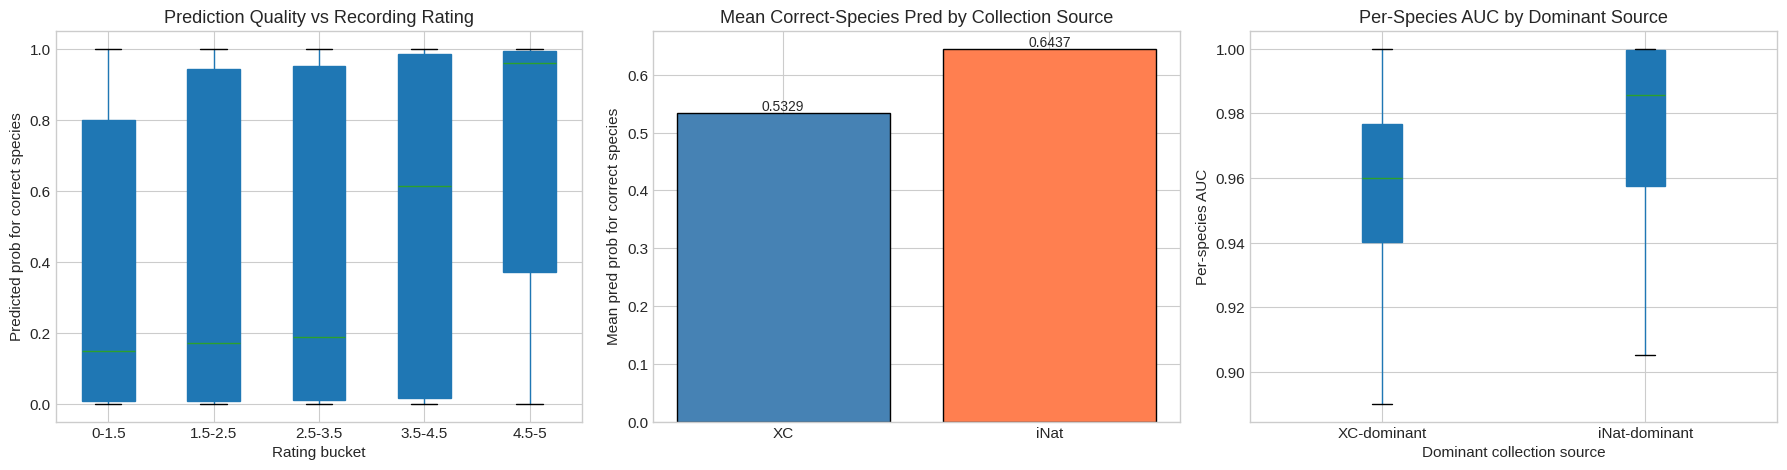

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── 6a. Rating vs prediction quality ────────────────────────────
ax = axes[0]
if 'rating' in oof_detail.columns and oof_detail['rating'].notna().any():
    oof_detail['rating_bucket'] = pd.cut(oof_detail['rating'],
                                          bins=[0, 1.5, 2.5, 3.5, 4.5, 5.5],
                                          labels=['0-1.5', '1.5-2.5', '2.5-3.5', '3.5-4.5', '4.5-5'])
    bp = oof_detail.boxplot(column='pred_correct_species', by='rating_bucket',
                             ax=ax, patch_artist=True, showfliers=False)
    ax.set_xlabel('Rating bucket')
    ax.set_ylabel('Predicted prob for correct species')
    ax.set_title('Prediction Quality vs Recording Rating')
    plt.suptitle('')  # remove auto-title from boxplot
else:
    ax.text(0.5, 0.5, 'No rating data available', ha='center', va='center',
            transform=ax.transAxes)

# ── 6b. Collection source comparison ────────────────────────────
ax = axes[1]
if 'collection' in oof_detail.columns:
    src_auc = oof_detail.groupby('collection')['pred_correct_species'].mean()
    ax.bar(src_auc.index, src_auc.values, color=['steelblue', 'coral'], edgecolor='black')
    ax.set_ylabel('Mean pred prob for correct species')
    ax.set_title('Mean Correct-Species Pred by Collection Source')
    for i, (src, val) in enumerate(src_auc.items()):
        ax.text(i, val + 0.005, f'{val:.4f}', ha='center', fontsize=10)

    # Also compare per-species AUC by dominant source
    ax2 = axes[2]
    sp_df_src = sp_df.dropna(subset=['auc']).copy()
    if 'n_XC' in sp_df_src.columns and 'n_iNat' in sp_df_src.columns:
        sp_df_src['dominant_src'] = np.where(sp_df_src['n_XC'] >= sp_df_src['n_iNat'], 'XC-dominant', 'iNat-dominant')
        bp = sp_df_src.boxplot(column='auc', by='dominant_src', ax=ax2,
                                patch_artist=True, showfliers=False)
        ax2.set_xlabel('Dominant collection source')
        ax2.set_ylabel('Per-species AUC')
        ax2.set_title('Per-Species AUC by Dominant Source')
        plt.suptitle('')
        # Add medians
        for label in ['XC-dominant', 'iNat-dominant']:
            sub = sp_df_src[sp_df_src['dominant_src'] == label]['auc']
            print(f'{label}: n={len(sub)}, median AUC={sub.median():.4f}, mean AUC={sub.mean():.4f}')
else:
    axes[1].text(0.5, 0.5, 'No collection data', ha='center', va='center',
                 transform=axes[1].transAxes)
    axes[2].text(0.5, 0.5, 'No collection data', ha='center', va='center',
                 transform=axes[2].transAxes)

plt.tight_layout()
plt.show()


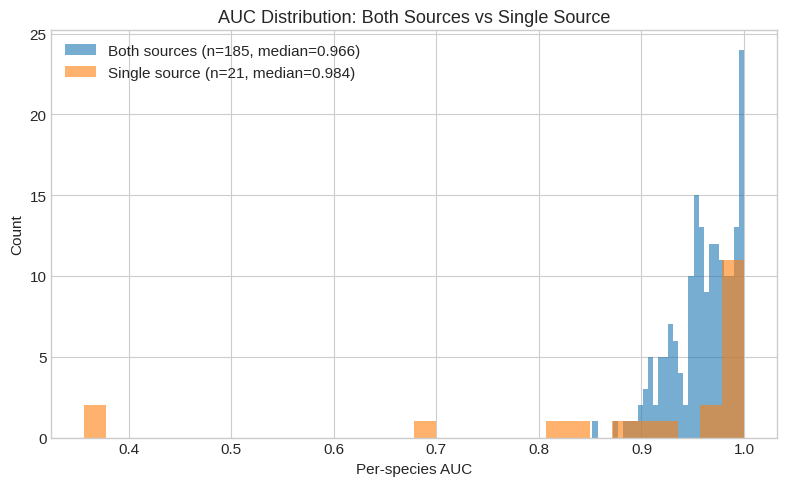

In [18]:
# ── 6c. Per-species AUC: species appearing in BOTH sources vs single source ──
if 'n_XC' in sp_df.columns and 'n_iNat' in sp_df.columns:
    sp_eval = sp_df.dropna(subset=['auc']).copy()
    sp_eval['in_both'] = (sp_eval['n_XC'] > 0) & (sp_eval['n_iNat'] > 0)
    sp_eval['source_coverage'] = sp_eval['in_both'].map({True: 'Both sources', False: 'Single source'})

    fig, ax = plt.subplots(figsize=(8, 5))
    for label, grp in sp_eval.groupby('source_coverage'):
        ax.hist(grp['auc'], bins=30, alpha=0.6, label=f'{label} (n={len(grp)}, median={grp["auc"].median():.3f})')
    ax.set_xlabel('Per-species AUC')
    ax.set_ylabel('Count')
    ax.set_title('AUC Distribution: Both Sources vs Single Source')
    ax.legend()
    plt.tight_layout()
    plt.show()


---
## Section 7 — Actionable Takeaways

In [20]:
# ── Generate a data-driven summary ───────────────────────────────
valid_sp = sp_df.dropna(subset=['auc'])
n_failing = (valid_sp['auc'] < 0.60).sum()
n_weak    = ((valid_sp['auc'] >= 0.60) & (valid_sp['auc'] < 0.80)).sum()
n_decent  = ((valid_sp['auc'] >= 0.80) & (valid_sp['auc'] < 0.95)).sum()
n_strong  = (valid_sp['auc'] >= 0.95).sum()

failing_sp = valid_sp[valid_sp['auc'] < 0.60]
non_aves_failing = failing_sp[failing_sp['class_name'] != 'Aves']
rare_failing = failing_sp[failing_sp['total_samples'] < 20]

# iNat-only species performance
inat_only = valid_sp[(valid_sp.get('n_XC', 0) == 0) & (valid_sp.get('n_iNat', 0) > 0)]
if len(inat_only) > 0:
    inat_only_median_auc = inat_only['auc'].median()
else:
    inat_only_median_auc = None

low_rating_sp = valid_sp[valid_sp['mean_rating'] < 2.5]
if len(low_rating_sp) > 0:
    low_rating_auc = low_rating_sp['auc'].median()
else:
    low_rating_auc = None

# Top confused pair
if len(conf_df) > 0:
    top_conf = conf_df.sort_values('mean_false_pred', ascending=False).iloc[0]
    top_conf_str = f"{top_conf['true_name']} ↔ {top_conf['confused_name']} (mean false pred = {top_conf['mean_false_pred']:.4f})"
else:
    top_conf_str = "N/A"

summary = f"""
### Summary of Findings

**Model status:** The baseline EfficientNet-B0 achieves a macro AUC of **{overall_auc:.4f}** on fold 0.
The training curves show {"clear overfitting (train loss << val loss)" if log['train_loss'].iloc[-1] < log['val_loss'].iloc[-1] * 0.9 else "mild overfitting with val loss plateauing in later epochs"}.
Best validation AUC was reached at epoch {best_ep}.

**Performance breakdown:**
- **{n_strong}** species with AUC ≥ 0.95 (strong)
- **{n_decent}** species with AUC 0.80–0.95 (decent)
- **{n_weak}** species with AUC 0.60–0.80 (weak)
- **{n_failing}** species with AUC < 0.60 (failing)

---

### Top 3 Sources of Error

1. **Rare / low-sample species:** {len(rare_failing)} of {n_failing} failing species have fewer than 20 training samples.
   Correlation between sample count and AUC confirms this is a primary driver.

2. **Non-bird taxa (Amphibia, Insecta, Mammalia, Reptilia):** {len(non_aves_failing)} of {n_failing} failing
   species are non-Aves. These taxa have very different spectral signatures that the ImageNet-pretrained
   backbone may not capture well.

3. **Cross-species confusion:** The most confused pair is **{top_conf_str}**.
   Some species pairs have genuinely similar vocalizations or share habitat/background noise.

---

### Species to Prioritize

The following species should be prioritized for improvement (sorted by impact on macro AUC):

{failing_sp[['species', 'common_name', 'class_name', 'auc', 'total_samples']].head(15).to_string(index=False)}

---

### Recommended Next Experiments

| Priority | Experiment | Rationale |
|----------|-----------|-----------|
| 1 | **Focal loss** or **class-weighted BCE** | Address rare-species underperformance; down-weight easy negatives |
| 2 | **Stronger backbone** (EfficientNet-B2/B3 or ConvNeXt) | Larger capacity should help with fine-grained discrimination |
| 3 | **Class-balanced sampling** | Oversample rare species and undersample common ones per epoch |
| 4 | **All 5 folds** | Increase effective training data and get more robust AUC estimates |
| 5 | **Duration / quality filtering** | Remove very short or low-rated clips that add noise |
| 6 | **Domain-specific augmentation** | Add random background mixing, pitch shift, time stretch |
| 7 | **Secondary label utilization** | Use secondary_labels for multi-label training to reduce confusion |
"""

display(Markdown(summary))



### Summary of Findings

**Model status:** The baseline EfficientNet-B0 achieves a macro AUC of **0.9535** on fold 0.
The training curves show clear overfitting (train loss << val loss).
Best validation AUC was reached at epoch 22.

**Performance breakdown:**
- **145** species with AUC ≥ 0.95 (strong)
- **58** species with AUC 0.80–0.95 (decent)
- **1** species with AUC 0.60–0.80 (weak)
- **2** species with AUC < 0.60 (failing)

---

### Top 3 Sources of Error

1. **Rare / low-sample species:** 2 of 2 failing species have fewer than 20 training samples.
   Correlation between sample count and AUC confirms this is a primary driver.

2. **Non-bird taxa (Amphibia, Insecta, Mammalia, Reptilia):** 2 of 2 failing
   species are non-Aves. These taxa have very different spectral signatures that the ImageNet-pretrained
   backbone may not capture well.

3. **Cross-species confusion:** The most confused pair is **Central Dwarf Frog ↔ Rufescent Tiger Heron (mean false pred = 0.7729)**.
   Some species pairs have genuinely similar vocalizations or share habitat/background noise.

---

### Species to Prioritize

The following species should be prioritized for improvement (sorted by impact on macro AUC):

species                common_name class_name      auc  total_samples
 116570 Southern Spectacled Caiman   Reptilia 0.359983            1.0
  23724      Waxy Monkey Tree Frog   Amphibia 0.356892            1.0

---

### Recommended Next Experiments

| Priority | Experiment | Rationale |
|----------|-----------|-----------|
| 1 | **Focal loss** or **class-weighted BCE** | Address rare-species underperformance; down-weight easy negatives |
| 2 | **Stronger backbone** (EfficientNet-B2/B3 or ConvNeXt) | Larger capacity should help with fine-grained discrimination |
| 3 | **Class-balanced sampling** | Oversample rare species and undersample common ones per epoch |
| 4 | **All 5 folds** | Increase effective training data and get more robust AUC estimates |
| 5 | **Duration / quality filtering** | Remove very short or low-rated clips that add noise |
| 6 | **Domain-specific augmentation** | Add random background mixing, pitch shift, time stretch |
| 7 | **Secondary label utilization** | Use secondary_labels for multi-label training to reduce confusion |


---
*End of notebook 06 — Error Analysis.  
Next step: pick the highest-impact experiment from the takeaways above.*